In [10]:
import numpy as np
import pandas as pd
import os
from tensorflow import keras
from tensorflow.keras import layers

In [11]:
# Load tabular dataset for shallow feedforward DNN
folder_path = os.path.normpath(os.path.join(os.getcwd(), '..', '..', '..', 'data', 'raw'))
path_main = os.path.join(folder_path, 'dataset_with_returns.csv')

print("Cargando dataset principal...")
df = pd.read_csv(path_main)

Cargando dataset principal...


In [12]:
df.head()

,date,open,high,low,close,volume,Name,adjusted_price,return_1d
0,2013-02-11,45.17,45.18,44.45,44.60,2915405,A,28.576422,-0.010648
1,2013-02-12,44.81,44.95,44.50,44.62,2373731,A,28.589230,0.000448
2,2013-02-13,44.81,45.24,44.68,44.75,2052338,A,28.672525,0.002914
3,2013-02-14,44.72,44.78,44.36,44.58,3826245,A,28.563612,-0.003799
4,2013-02-15,43.48,44.24,42.21,42.25,14657315,A,27.070713,-0.052266


## Split in train and test

In [13]:
def temporal_train_test_split(df, train_ratio=0.75):
    train_dfs = []
    test_dfs = []

    # Per-ticker temporal split when ticker is available
    if "ticker" in df.columns:
        df = df.copy()
        df["time_idx"] = df.groupby("ticker").cumcount()

        for ticker in df["ticker"].unique():
            df_t = df[df["ticker"] == ticker].sort_values("time_idx")
            n = len(df_t)
            train_size = int(train_ratio * n)

            train_dfs.append(df_t.iloc[:train_size])
            test_dfs.append(df_t.iloc[train_size:])

        df_train = pd.concat(train_dfs).reset_index(drop=True)
        df_test = pd.concat(test_dfs).reset_index(drop=True)
        return df_train, df_test

    # Fallback temporal split by date/index when ticker is not available
    df_sorted = df.copy()
    if "date" in df_sorted.columns:
        df_sorted["date"] = pd.to_datetime(df_sorted["date"], errors="coerce")
        df_sorted = df_sorted.sort_values("date")

    split_idx = int(train_ratio * len(df_sorted))
    df_train = df_sorted.iloc[:split_idx].reset_index(drop=True)
    df_test = df_sorted.iloc[split_idx:].reset_index(drop=True)
    return df_train, df_test

In [14]:
df_train, df_test = temporal_train_test_split(df)

In [15]:
print(df_train.shape)
print(df_test.shape)

if "ticker" in df_train.columns:
    print(df_train.groupby("ticker").size().head())
    print(df_test.groupby("ticker").size().head())
else:
    print("'ticker' column not present; temporal split used date/index fallback.")

(463901, 9)
(154634, 9)
'ticker' column not present; temporal split used date/index fallback.


In [17]:

# =============================================================================
# PHASE 1 — DATA PREPARATION
# =============================================================================


def build_research_dataset_from_df(input_df):
    required_cols = {"date", "open", "high", "low", "close", "volume", "Name", "adjusted_price", "return_1d"}
    missing_cols = required_cols.difference(input_df.columns)
    if missing_cols:
        raise ValueError(f"Dataset is missing required columns: {sorted(missing_cols)}")

    work_df = input_df.copy()
    work_df["date"] = pd.to_datetime(work_df["date"], errors="coerce")
    work_df = work_df.dropna(subset=["date", "Name"]).sort_values(["Name", "date"]).reset_index(drop=True)

    price_eps = 1e-6
    grouped = work_df.groupby("Name", group_keys=False)

    work_df["intraday_return"] = (work_df["close"] - work_df["open"]) / np.maximum(np.abs(work_df["open"]), price_eps)
    work_df["high_low_range"] = (work_df["high"] - work_df["low"]) / np.maximum(np.abs(work_df["close"]), price_eps)
    work_df["close_to_high"] = (work_df["high"] - work_df["close"]) / np.maximum(np.abs(work_df["close"]), price_eps)
    work_df["close_to_low"] = (work_df["close"] - work_df["low"]) / np.maximum(np.abs(work_df["close"]), price_eps)
    work_df["open_to_high"] = (work_df["high"] - work_df["open"]) / np.maximum(np.abs(work_df["open"]), price_eps)
    work_df["open_to_low"] = (work_df["open"] - work_df["low"]) / np.maximum(np.abs(work_df["open"]), price_eps)
    work_df["log_volume"] = np.log1p(np.clip(work_df["volume"], a_min=0.0, a_max=None))
    work_df["adjusted_close_gap"] = (work_df["adjusted_price"] - work_df["close"]) / np.maximum(np.abs(work_df["close"]), price_eps)

    for lag in [1, 2, 3, 5, 10]:
        work_df[f"return_lag_{lag}"] = grouped["return_1d"].shift(lag)

    volume_pct_change = grouped["volume"].pct_change().replace([np.inf, -np.inf], np.nan)
    for lag in [1, 2, 3]:
        work_df[f"volume_change_lag_{lag}"] = grouped["volume"].shift(lag).pct_change().replace([np.inf, -np.inf], np.nan)

    for window in [3, 5, 10]:
        work_df[f"return_mean_{window}"] = grouped["return_1d"].transform(lambda series: series.rolling(window).mean())
        work_df[f"return_std_{window}"] = grouped["return_1d"].transform(lambda series: series.rolling(window).std())
        rolling_volume_mean = grouped["volume"].transform(lambda series: series.rolling(window).mean())
        work_df[f"volume_vs_mean_{window}"] = work_df["volume"] / np.maximum(rolling_volume_mean, price_eps) - 1.0

    adj_return = grouped["adjusted_price"].pct_change().replace([np.inf, -np.inf], np.nan)
    for horizon in [2, 3, 5, 10, 20]:
        work_df[f"adj_momentum_{horizon}"] = grouped["adjusted_price"].pct_change(horizon).replace([np.inf, -np.inf], np.nan)

    work_df["future_return_1d"] = grouped["adjusted_price"].pct_change().shift(-1)
    work_df["target_bin"] = (work_df["future_return_1d"] > 0).astype(np.float32)

    feature_cols = [
        "return_1d",
        "intraday_return",
        "high_low_range",
        "close_to_high",
        "close_to_low",
        "open_to_high",
        "open_to_low",
        "log_volume",
        "adjusted_close_gap",
        "return_lag_1",
        "return_lag_2",
        "return_lag_3",
        "return_lag_5",
        "return_lag_10",
        "volume_change_lag_1",
        "volume_change_lag_2",
        "volume_change_lag_3",
        "return_mean_3",
        "return_mean_5",
        "return_mean_10",
        "return_std_3",
        "return_std_5",
        "return_std_10",
        "volume_vs_mean_3",
        "volume_vs_mean_5",
        "volume_vs_mean_10",
        "adj_momentum_2",
        "adj_momentum_3",
        "adj_momentum_5",
        "adj_momentum_10",
        "adj_momentum_20",
    ]

    model_df = work_df.dropna(subset=feature_cols + ["target_bin"]).copy()
    if model_df.empty:
        raise ValueError("Feature engineering produced an empty dataset. Check the raw data coverage.")

    X_fallback = model_df[feature_cols].to_numpy(dtype=np.float32)
    y_fallback = model_df["target_bin"].to_numpy(dtype=np.float32)
    dates_fallback = model_df["date"].to_numpy()

    return X_fallback, y_fallback, dates_fallback, feature_cols


# Resolve source arrays from available notebook variables
if "X_np" in globals() and "y_np" in globals():
    X_all = np.asarray(X_np, dtype=np.float32)
    y_all = np.asarray(y_np, dtype=np.float32).reshape(-1)
    split_dates = None
    feature_names_shallow = [f"feature_{idx}" for idx in range(X_all.shape[1])]
elif "X_train_np" in globals() and "y_train_np" in globals():
    X_all = np.asarray(X_train_np, dtype=np.float32)
    y_all = np.asarray(y_train_np, dtype=np.float32).reshape(-1)
    split_dates = None
    feature_names_shallow = [f"feature_{idx}" for idx in range(X_all.shape[1])]
elif "df" in globals():
    X_all, y_all, split_dates, feature_names_shallow = build_research_dataset_from_df(df)
else:
    raise ValueError("No prepared arrays or dataframe found. Run the dataset loading cell first.")

if X_all.ndim != 2 or X_all.shape[1] < 31:
    raise ValueError(f"Expected 2D array with >= 31 features, got shape {X_all.shape}.")
X_all = X_all[:, :31]
feature_names_shallow = feature_names_shallow[:31]

# Binary target: BUY (1) vs NOT-BUY (0)
y_bin = (y_all > 0).astype(np.float32)

# Reproducible holdout split
if split_dates is None:
    rng = np.random.default_rng(42)
    perm = rng.permutation(len(X_all))
    cut = int(0.80 * len(perm))
    train_idx = perm[:cut]
    val_idx = perm[cut:]
else:
    order = np.argsort(split_dates)
    cut = int(0.80 * len(order))
    train_idx = order[:cut]
    val_idx = order[cut:]

X_train_shallow_raw = X_all[train_idx]
y_train_shallow = y_bin[train_idx]
X_val_shallow_raw = X_all[val_idx]
y_val_shallow = y_bin[val_idx]

# =============================================================================
# PHASE 2 — FEATURE STANDARDISATION  (fit on train only — no data leakage)
# =============================================================================

feature_mean = X_train_shallow_raw.mean(axis=0, keepdims=True)
feature_std = X_train_shallow_raw.std(axis=0, keepdims=True)
feature_std = np.where(feature_std < 1e-6, 1.0, feature_std)

X_train_shallow = (X_train_shallow_raw - feature_mean) / feature_std
X_val_shallow = (X_val_shallow_raw - feature_mean) / feature_std

# =============================================================================
# PHASE 3 — CLASS WEIGHTING
# =============================================================================

n_neg = float(np.sum(y_train_shallow == 0))
n_pos = float(np.sum(y_train_shallow == 1))
if n_pos == 0:
    raise ValueError("No positive samples in training set.")

if n_neg == 0:
    raise ValueError("No negative samples in training set.")

total = n_neg + n_pos
class_weight = {0: total / (2.0 * n_neg), 1: total / (2.0 * n_pos)}

# =============================================================================
# PHASE 4 — MODEL DEFINITION
# =============================================================================

positive_rate = float(np.clip(np.mean(y_train_shallow), 1e-6, 1 - 1e-6))
initial_bias = float(np.log(positive_rate / (1.0 - positive_rate)))

shallow_model = keras.Sequential([
    layers.Input(shape=(31,)),
    layers.Dense(500, activation="relu"),
    layers.Dense(
        1,
        activation="sigmoid",
        kernel_regularizer=keras.regularizers.l2(1e-4),
        bias_initializer=keras.initializers.Constant(initial_bias),
    ),
], name="shallow_binary_classifier")

shallow_model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

# =============================================================================
# PHASE 5 — TRAINING
# =============================================================================

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True,
)

history_shallow = shallow_model.fit(
    X_train_shallow,
    y_train_shallow,
    validation_data=(X_val_shallow, y_val_shallow),
    epochs=30,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stopping],
    verbose=1,
)

print(f"\nTraining complete | positive rate: {positive_rate:.4f}")
print(f"Train samples: {len(train_idx)} | Validation samples: {len(val_idx)}")
print(f"Using {X_all.shape[1]} features.")
print(f"Class weights: {class_weight}")


Epoch 1/30
1902/1902 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5188 - auc: 0.5247 - loss: 0.6944 - val_accuracy: 0.5180 - val_auc: 0.5087 - val_loss: 0.7051
Epoch 2/30
1902/1902 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5230 - auc: 0.5317 - loss: 0.6924 - val_accuracy: 0.5070 - val_auc: 0.5003 - val_loss: 0.6966
Epoch 3/30
1902/1902 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5236 - auc: 0.5332 - loss: 0.6918 - val_accuracy: 0.5074 - val_auc: 0.5090 - val_loss: 0.6984
Epoch 4/30
1902/1902 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5252 - auc: 0.5351 - loss: 0.6915 - val_accuracy: 0.5048 - val_auc: 0.5116 - val_loss: 0.6968
Epoch 5/30
1902/1902 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5263 - auc: 0.5372 - loss: 0.6910 - val_accuracy: 0.5049 - val_auc: 0.5073 - val_loss: 0.6969
Epoch 6/30
1902/1902 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.5271 - auc: 0.5387 - loss: 0.6909 - val_accuracy: 0.5158 - val_auc: 0.5105 - val_loss: 0.6956
Epoch 7/30
1902/1902 ━━━━━━━

In [18]:
# Quick target sanity check
print("y_train_shallow min/max:", float(np.min(y_train_shallow)), float(np.max(y_train_shallow)))
print("y_val_shallow min/max:", float(np.min(y_val_shallow)), float(np.max(y_val_shallow)))
print("Unique y values in validation (first 20):", np.unique(y_val_shallow)[:20])
print("Count y==0:", int(np.sum(y_val_shallow == 0)))
print("Count y==1:", int(np.sum(y_val_shallow == 1)))

y_train_shallow min/max: 0.0 1.0
y_val_shallow min/max: 0.0 1.0
Unique y values in validation (first 20): [0. 1.]
Count y==0: 57645
Count y==1: 64040


In [19]:

# =============================================================================
# PHASE 1 — VALIDATION PREDICTION
# =============================================================================

if "shallow_model" not in globals():
    raise ValueError("shallow_model not found. Run the Training cell first.")

val_results = shallow_model.evaluate(X_val_shallow, y_val_shallow, verbose=0, return_dict=True)
y_prob_shallow = shallow_model.predict(X_val_shallow, verbose=0).reshape(-1)
y_true_shallow = y_val_shallow.astype(np.int32)

val_loss_shallow = float(val_results["loss"])
val_acc_shallow = float(val_results["accuracy"])
val_auc_shallow = float(val_results["auc"])

# =============================================================================
# PHASE 2 — VECTORISED THRESHOLD OPTIMISATION  (objective: maximise F1)
# =============================================================================

thresholds = np.linspace(0.01, 0.99, 500)
pred_matrix = y_prob_shallow[:, None] >= thresholds[None, :]
y_col = y_true_shallow[:, None].astype(bool)

tp_vec = np.sum(pred_matrix & y_col, axis=0, dtype=np.int64).astype(np.float64)
fp_vec = np.sum(pred_matrix & ~y_col, axis=0, dtype=np.int64).astype(np.float64)
fn_vec = np.sum(~pred_matrix & y_col, axis=0, dtype=np.int64).astype(np.float64)

tp_fp_sum = tp_vec + fp_vec
tp_fn_sum = tp_vec + fn_vec

prec_vec = np.divide(tp_vec, tp_fp_sum, out=np.zeros_like(tp_vec), where=tp_fp_sum > 0)
rec_vec = np.divide(tp_vec, tp_fn_sum, out=np.zeros_like(tp_vec), where=tp_fn_sum > 0)
f1_numerator = 2.0 * prec_vec * rec_vec
f1_denominator = prec_vec + rec_vec
f1_vec = np.divide(f1_numerator, f1_denominator, out=np.zeros_like(f1_numerator), where=f1_denominator > 0)

best_idx = int(np.argmax(f1_vec))
best_threshold = float(thresholds[best_idx])
best_precision = float(prec_vec[best_idx])
best_recall = float(rec_vec[best_idx])
best_f1 = float(f1_vec[best_idx])

y_pred_shallow = (y_prob_shallow >= best_threshold).astype(np.int32)

# =============================================================================
# PHASE 3 — SUMMARY
# =============================================================================

print(f"Validation Loss:     {val_loss_shallow:.4f}")
print(f"Validation Accuracy: {val_acc_shallow:.4f}")
print(f"Validation AUC:      {val_auc_shallow:.4f}")
print(f"Best threshold (max F1): {best_threshold:.4f}")
print(f"  Precision: {best_precision:.4f}")
print(f"  Recall:    {best_recall:.4f}")
print(f"  F1:        {best_f1:.4f}")


Validation Loss:     0.6964
Validation Accuracy: 0.5098
Validation AUC:      0.5145
Best threshold (max F1): 0.2732
  Precision: 0.5268
  Recall:    0.9994
  F1:        0.6899


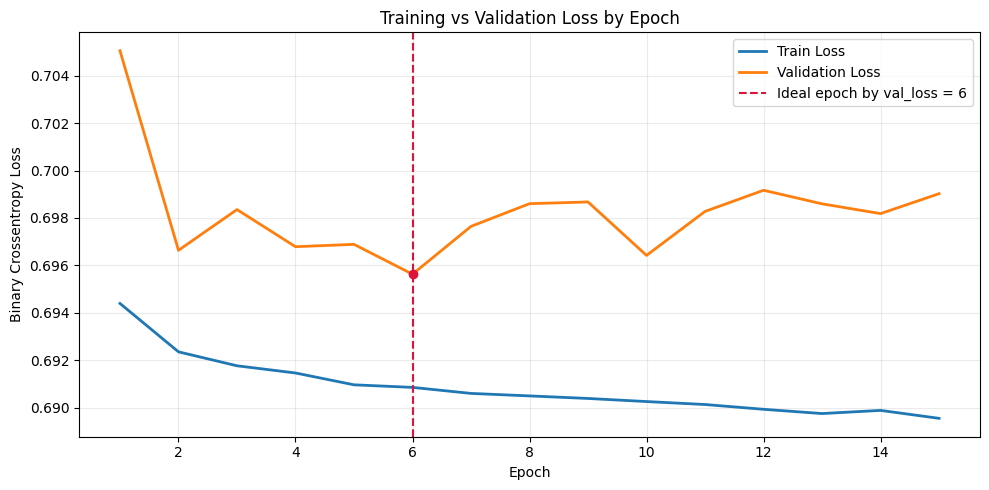

Ideal epoch based on minimum validation loss: 6
Training loss at ideal epoch: 0.6909
Validation loss at ideal epoch: 0.6956
Best epoch based on maximum validation AUC: 10
Validation AUC at that epoch: 0.5145
Threshold:            0.2732
Precision:            0.5268
Recall:               0.9994
F1:                   0.6899
Accuracy:             0.5272
AUC (ROC):            0.5145
Positive predictions: 121497
Confusion Matrix  ->  TN: 152  FP: 57493  FN: 36  TP: 64004


In [21]:
# =============================================================================
# TRAINING DIAGNOSTICS — epochs vs loss
# =============================================================================

if "history_shallow" not in globals():
    raise ValueError("history_shallow not found. Run the Training cell first.")

import matplotlib.pyplot as plt

history_frame = pd.DataFrame(history_shallow.history)
history_frame.index = np.arange(1, len(history_frame) + 1)
history_frame.index.name = "epoch"

if "loss" not in history_frame.columns or "val_loss" not in history_frame.columns:
    raise ValueError("Training history does not contain loss and val_loss.")

ideal_epoch_val_loss = int(history_frame["val_loss"].idxmin())
best_train_loss = float(history_frame.loc[ideal_epoch_val_loss, "loss"])
best_val_loss = float(history_frame.loc[ideal_epoch_val_loss, "val_loss"])

plt.figure(figsize=(10, 5))
plt.plot(history_frame.index, history_frame["loss"], label="Train Loss", linewidth=2)
plt.plot(history_frame.index, history_frame["val_loss"], label="Validation Loss", linewidth=2)
plt.axvline(
    ideal_epoch_val_loss,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label=f"Ideal epoch by val_loss = {ideal_epoch_val_loss}",
)
plt.scatter([ideal_epoch_val_loss], [best_val_loss], color="crimson", zorder=5)
plt.title("Training vs Validation Loss by Epoch")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Ideal epoch based on minimum validation loss: {ideal_epoch_val_loss}")
print(f"Training loss at ideal epoch: {best_train_loss:.4f}")
print(f"Validation loss at ideal epoch: {best_val_loss:.4f}")

if "val_auc" in history_frame.columns:
    ideal_epoch_val_auc = int(history_frame["val_auc"].idxmax())
    best_val_auc_history = float(history_frame.loc[ideal_epoch_val_auc, "val_auc"])
    print(f"Best epoch based on maximum validation AUC: {ideal_epoch_val_auc}")
    print(f"Validation AUC at that epoch: {best_val_auc_history:.4f}")

# =============================================================================
# METRICS  — final evaluation at the threshold selected in the Validation cell
# =============================================================================

tp = int(np.sum((y_pred_shallow == 1) & (y_true_shallow == 1)))
tn = int(np.sum((y_pred_shallow == 0) & (y_true_shallow == 0)))
fp = int(np.sum((y_pred_shallow == 1) & (y_true_shallow == 0)))
fn = int(np.sum((y_pred_shallow == 0) & (y_true_shallow == 1)))

precision_shallow = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall_shallow    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1_shallow        = (
    2.0 * precision_shallow * recall_shallow / (precision_shallow + recall_shallow)
    if (precision_shallow + recall_shallow) > 0 else 0.0
)
acc_shallow = (tp + tn) / (tp + tn + fp + fn)

auc_metric_shallow = keras.metrics.AUC()
auc_metric_shallow.update_state(y_true_shallow, y_prob_shallow)
auc_shallow = float(auc_metric_shallow.result().numpy())

print(f"Threshold:            {best_threshold:.4f}")
print(f"Precision:            {precision_shallow:.4f}")
print(f"Recall:               {recall_shallow:.4f}")
print(f"F1:                   {f1_shallow:.4f}")
print(f"Accuracy:             {acc_shallow:.4f}")
print(f"AUC (ROC):            {auc_shallow:.4f}")
print(f"Positive predictions: {tp + fp}")
print(f"Confusion Matrix  ->  TN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")


In [ ]:
print(y_prob_shallow.min(), y_prob_shallow.max())

In [ ]:
# =============================================================================
# SHALLOW NETWORK — TRAINING + VALIDATION
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve

# ── Resolve source arrays ─────────────────────────────────────────────────────
if "X_np" in globals() and "y_np" in globals():
    X_all = np.asarray(X_np, dtype=np.float32)
    y_all = np.asarray(y_np, dtype=np.float32).reshape(-1)
elif "X_train_np" in globals() and "y_train_np" in globals():
    X_all = np.asarray(X_train_np, dtype=np.float32)
    y_all = np.asarray(y_train_np, dtype=np.float32).reshape(-1)
elif "X_all" in globals() and "y_bin" in globals():
    X_all = np.asarray(X_all, dtype=np.float32)
    y_all = np.asarray(y_bin, dtype=np.float32).reshape(-1)
elif "df" in globals():
    if "build_research_dataset_from_df" not in globals():
        raise ValueError("build_research_dataset_from_df no esta disponible. Ejecuta primero la celda de preparacion de datos.")
    X_all, y_all, _, _ = build_research_dataset_from_df(df)
else:
    raise ValueError("No se encontraron arrays base. Ejecuta primero la preparacion de datos.")

if X_all.ndim != 2:
    raise ValueError(f"X debe ser 2D. Shape recibido: {X_all.shape}")
if X_all.shape[1] < 31:
    raise ValueError(f"Se requieren al menos 31 features, se encontraron {X_all.shape[1]}")

X_all = X_all[:, :31]
y_bin = (y_all > 0).astype(np.float32)

# ── Holdout split 80/20 ───────────────────────────────────────────────────────
rng = np.random.default_rng(42)
idx = np.arange(len(X_all))
rng.shuffle(idx)
cut        = int(0.8 * len(idx))
train_idx  = idx[:cut]
val_idx    = idx[cut:]

X_train_shallow_raw = X_all[train_idx];  y_train_shallow = y_bin[train_idx]
X_val_shallow_raw   = X_all[val_idx];    y_val_shallow   = y_bin[val_idx]

# ── Standardize on train stats only ──────────────────────────────────────────
feature_mean = X_train_shallow_raw.mean(axis=0, keepdims=True)
feature_std  = X_train_shallow_raw.std(axis=0,  keepdims=True)
feature_std  = np.where(feature_std < 1e-6, 1.0, feature_std)

X_train_shallow = (X_train_shallow_raw - feature_mean) / feature_std
X_val_shallow   = (X_val_shallow_raw   - feature_mean) / feature_std

# ── Class weights ─────────────────────────────────────────────────────────────
negative_count = float(np.sum(y_train_shallow == 0))
positive_count = float(np.sum(y_train_shallow == 1))
if positive_count == 0:
    raise ValueError("No hay positivos en el set de entrenamiento.")
if negative_count == 0:
    raise ValueError("No hay negativos en el set de entrenamiento.")

total        = negative_count + positive_count
class_weight = {0: total / (2.0 * negative_count), 1: total / (2.0 * positive_count)}

# ── Bias init ─────────────────────────────────────────────────────────────────
positive_rate = float(np.clip(np.mean(y_train_shallow), 1e-6, 1 - 1e-6))
initial_bias  = float(np.log(positive_rate / (1.0 - positive_rate)))

# ── Model ─────────────────────────────────────────────────────────────────────
shallow_model = keras.Sequential([
    layers.Input(shape=(31,)),
    layers.Dense(100, activation="relu"),
    layers.Dense(
        1,
        activation="sigmoid",
        kernel_regularizer=keras.regularizers.l2(1e-4),
        bias_initializer=keras.initializers.Constant(initial_bias),
    ),
], name="shallow_binary_classifier")

shallow_model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

# ── Training ──────────────────────────────────────────────────────────────────
history_shallow = shallow_model.fit(
    X_train_shallow, y_train_shallow,
    validation_data=(X_val_shallow, y_val_shallow),
    epochs=30,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max",
            patience=5, restore_best_weights=True,
        )
    ],
    verbose=1,
)

print(f"\nTraining complete  |  positive rate: {positive_rate:.4f}")
print(f"Class weights: {class_weight}")

# =============================================================================
# VALIDATION — threshold search
# =============================================================================

val_results    = shallow_model.evaluate(X_val_shallow, y_val_shallow, verbose=0, return_dict=True)
y_prob_shallow = shallow_model.predict(X_val_shallow, verbose=0).reshape(-1)
y_true_shallow = y_val_shallow.astype(np.int32)

precision_floor      = 0.33
threshold_candidates = np.linspace(0.30, 0.99, 70)
best_threshold = 0.50
best_precision = best_recall = best_f1 = 0.0

for thr in threshold_candidates:
    p = (y_prob_shallow >= thr).astype(np.int32)
    _tp = np.sum((p == 1) & (y_true_shallow == 1))
    _fp = np.sum((p == 1) & (y_true_shallow == 0))
    _fn = np.sum((p == 0) & (y_true_shallow == 1))
    _pr = _tp / (_tp + _fp) if (_tp + _fp) > 0 else 0.0
    _rc = _tp / (_tp + _fn) if (_tp + _fn) > 0 else 0.0
    _f1 = 2 * _pr * _rc / (_pr + _rc) if (_pr + _rc) > 0 else 0.0
    if _pr >= precision_floor and _rc > best_recall:
        best_threshold, best_precision, best_recall, best_f1 = float(thr), _pr, _rc, _f1

# Fallback: maximize F1 if precision floor unreachable
if best_recall == 0.0:
    for thr in threshold_candidates:
        p = (y_prob_shallow >= thr).astype(np.int32)
        _tp = np.sum((p == 1) & (y_true_shallow == 1))
        _fp = np.sum((p == 1) & (y_true_shallow == 0))
        _fn = np.sum((p == 0) & (y_true_shallow == 1))
        _pr = _tp / (_tp + _fp) if (_tp + _fp) > 0 else 0.0
        _rc = _tp / (_tp + _fn) if (_tp + _fn) > 0 else 0.0
        _f1 = 2 * _pr * _rc / (_pr + _rc) if (_pr + _rc) > 0 else 0.0
        if _f1 > best_f1:
            best_threshold, best_precision, best_recall, best_f1 = float(thr), _pr, _rc, _f1

y_pred_shallow = (y_prob_shallow >= best_threshold).astype(np.int32)

print(f"\nValidation Loss     : {val_results['loss']:.4f}")
print(f"Validation Accuracy : {val_results['accuracy']:.4f}")
print(f"Validation AUC      : {val_results['auc']:.4f}")
print(f"Selected threshold  : {best_threshold:.2f}  (precision floor: {precision_floor:.2f})")
print("Validation complete.")

# =============================================================================
# METRICS — dashboard
# =============================================================================

# ── Final confusion matrix at chosen threshold ────────────────────────────────
tp = int(np.sum((y_pred_shallow == 1) & (y_true_shallow == 1)))
tn = int(np.sum((y_pred_shallow == 0) & (y_true_shallow == 0)))
fp = int(np.sum((y_pred_shallow == 1) & (y_true_shallow == 0)))
fn = int(np.sum((y_pred_shallow == 0) & (y_true_shallow == 1)))

precision_m   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall_m      = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1_m          = 2 * precision_m * recall_m / (precision_m + recall_m) if (precision_m + recall_m) > 0 else 0.0
accuracy_m    = (tp + tn) / (tp + tn + fp + fn)
specificity_m = tn / (tn + fp) if (tn + fp) > 0 else 0.0

auc_obj = keras.metrics.AUC()
auc_obj.update_state(y_true_shallow, y_prob_shallow)
roc_auc = float(auc_obj.result().numpy())

fpr, tpr, _         = roc_curve(y_true_shallow, y_prob_shallow)
frac_pos, mean_pred = calibration_curve(y_true_shallow, y_prob_shallow, n_bins=15, strategy="quantile")

hist       = pd.DataFrame(history_shallow.history)
hist.index = np.arange(1, len(hist) + 1)
best_epoch = int(hist["val_auc"].idxmax())

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 11))
fig.suptitle("Shallow Network — Evaluation Dashboard", fontsize=15, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.32)

TRAIN_COLOR = "#4C72B0"
VAL_COLOR   = "#DD8452"
REF_COLOR   = "#555555"

# 1 · Loss curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(hist.index, hist["loss"],     color=TRAIN_COLOR, linewidth=2,   label="Train")
ax1.plot(hist.index, hist["val_loss"], color=VAL_COLOR,   linewidth=2,   label="Validation")
ax1.axvline(best_epoch, color="crimson", linestyle="--", linewidth=1.4,
            label=f"Best epoch ({best_epoch})")
ax1.set_title("Loss per Epoch", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Binary Crossentropy")
ax1.legend(fontsize=8); ax1.grid(alpha=0.25)

# 2 · AUC curves
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(hist.index, hist["auc"],     color=TRAIN_COLOR, linewidth=2, label="Train")
ax2.plot(hist.index, hist["val_auc"], color=VAL_COLOR,   linewidth=2, label="Validation")
ax2.axvline(best_epoch, color="crimson", linestyle="--", linewidth=1.4,
            label=f"Best epoch ({best_epoch})")
ax2.set_title("AUC per Epoch", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("ROC AUC")
ax2.legend(fontsize=8); ax2.grid(alpha=0.25)

# 3 · ROC curve
ax3 = fig.add_subplot(gs[1, 0])
ax3.fill_between(fpr, tpr, alpha=0.08, color=TRAIN_COLOR)
ax3.plot(fpr, tpr, color=TRAIN_COLOR, linewidth=2.5, label=f"AUC = {roc_auc:.4f}")
ax3.plot([0, 1], [0, 1], color=REF_COLOR, linestyle="--", linewidth=1.2, label="Random  (0.5000)")
ax3.set_title("ROC Curve — Validation Set", fontweight="bold")
ax3.set_xlabel("False Positive Rate"); ax3.set_ylabel("True Positive Rate")
ax3.legend(fontsize=9); ax3.grid(alpha=0.25)

# 4 · Calibration curve
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(mean_pred, frac_pos, "o-", color=VAL_COLOR, linewidth=2.5,
         markersize=5, label="Model")
ax4.plot([0, 1], [0, 1], color=REF_COLOR, linestyle="--", linewidth=1.2,
         label="Perfect calibration")
ax4.set_title("Calibration Curve — Validation Set", fontweight="bold")
ax4.set_xlabel("Mean Predicted Probability")
ax4.set_ylabel("Fraction of Positives")
ax4.legend(fontsize=9); ax4.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ── Printed summary ───────────────────────────────────────────────────────────
print("\n" + "=" * 56)
print("  SHALLOW MODEL — VALIDATION SET METRICS")
print("=" * 56)
print(f"  Threshold (precision-floor search) : {best_threshold:.4f}")
print(f"  Best epoch (max val AUC)           : {best_epoch} / {len(hist)}")
print("-" * 56)
print(f"  AUC  (ROC)      : {roc_auc:.4f}")
print(f"  Accuracy        : {accuracy_m:.4f}")
print(f"  Precision       : {precision_m:.4f}")
print(f"  Recall          : {recall_m:.4f}")
print(f"  Specificity     : {specificity_m:.4f}")
print(f"  F1 Score        : {f1_m:.4f}")
print("-" * 56)
print("  Confusion Matrix")
print(f"              Pred 0   Pred 1")
print(f"  Actual 0  {tn:>8,} {fp:>8,}   (TN / FP)")
print(f"  Actual 1  {fn:>8,} {tp:>8,}   (FN / TP)")
print("=" * 56)

# ── Diagnostic warnings ───────────────────────────────────────────────────────
if roc_auc < 0.52:
    print("\nWarning: AUC < 0.52 — model is barely above random.")
if recall_m > 0.95 and precision_m < 0.55:
    print("\nWarning: Recall ≈ 1.0 with low precision — threshold may be too low.")
if specificity_m < 0.10:
    print("\nWarning: Specificity very low — model rarely predicts class 0.")

ValueError: No se encontraron arrays base. Ejecuta primero la preparacion de datos.